# Custom Residual CNN for 5-Class Flower Classification

This notebook demonstrates how to build and train a custom Convolutional Neural Network featuring **Residual Blocks (Skip Connections)** from scratch using PyTorch.

We train a `MediumCNN` architecture to classify images into 5 flower categories (Daisy, Dandelion, Rose, Sunflower, Tulip).

**Key Concepts Covered:**
1. **Deterministic Validation and Test Transforms:** Random augmentation is used only for training. Validation and test images use deterministic preprocessing.
2. **Manual Dataset Splitting:** The original dataset is split into train, validation, and test subsets without overlap.
3. **Custom ResNet Architecture:** Residual blocks use skip connections to make deeper convolutional networks easier to optimize.
4. **Native PyTorch Training Loop:** Training and evaluation are implemented directly with PyTorch.
5. **Best-Model Selection:** The checkpoint with the best validation accuracy is saved and reloaded before final testing.
6. **Quantitative Test Evaluation:** The untouched test split is evaluated using accuracy, precision, recall, F1-score, and a confusion matrix.
7. **Multiple Test Examples:** Individual predictions are inspected using known test labels.

### Training and Evaluation Protocol

The original dataset is divided into three non-overlapping subsets:

- **Train:** used to update model parameters.
- **Validation:** used to monitor training and select the best checkpoint.
- **Test:** kept untouched until final evaluation.

The final test metrics are therefore not used to select the model.

This is a small controlled image-classification experiment, not a benchmark.


In [ ]:
import os
import random
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import urllib.request
import tarfile
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

seed = 42
epochs = 50



random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


## Dataset

The TensorFlow flower photos dataset contains five flower classes.

A single `ImageFolder` is used to obtain the labels and file ordering. The same indices are then applied to separate dataset objects with different transforms, so the train/validation/test split remains identical while augmentation is used only for training.


In [ ]:
extract_dir = "/content/flower_photos"
root_dir = "/content/flower_photos"

url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
file_path = "/content/flower_photos.tgz"

if not os.path.exists(extract_dir):
    print("Downloading 5-class Flowers dataset...")
    urllib.request.urlretrieve(url, file_path)

    with tarfile.open(file_path, "r:gz") as tar:
        tar.extractall(path="/content")

    print("Dataset extracted successfully.")


/tmp/ipykernel_1707/1510844109.py:12: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path="/content")


Dataset extracted successfully.


In [ ]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

test_transform = val_transform

train_dataset = datasets.ImageFolder(root=root_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(root=root_dir, transform=val_transform)
test_dataset = datasets.ImageFolder(root=root_dir, transform=test_transform)

print("Number of classes:", len(train_dataset.classes))
print("Class names:", train_dataset.classes)

dataset_size = len(train_dataset)
indices = torch.randperm(dataset_size, generator=torch.Generator().manual_seed(seed)).tolist()

train_ratio = 0.70
val_ratio = 0.15

train_size = int(train_ratio * dataset_size)
val_size = int(val_ratio * dataset_size)

train_indices = indices[:train_size]
val_indices = indices[train_size:train_size + val_size]
test_indices = indices[train_size + val_size:]

train_data = Subset(train_dataset, train_indices)
val_data = Subset(val_dataset, val_indices)
test_data = Subset(test_dataset, test_indices)

print(f"Train samples: {len(train_data)}")
print(f"Val samples:   {len(val_data)}")
print(f"Test samples:  {len(test_data)}")


Number of classes: 5
Class names: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
Train samples: 2569
Val samples:   550
Test samples:  551


## DataLoaders

The training loader is shuffled because the order of training examples should not be fixed.

Validation and test loaders are not shuffled. Their order does not affect the metrics, but keeping evaluation deterministic makes individual prediction inspection easier.


In [ ]:
batch_size = 8

train_loader = DataLoader(
    train_data,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_data,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_data,
    batch_size=batch_size,
    shuffle=False
)


## Residual CNN

The residual block adds the input to the output of two convolutional layers.

When the number of channels or spatial resolution changes, a `1x1` convolution in the skip path matches the dimensions.

The model is intentionally implemented directly in PyTorch rather than using a prebuilt ResNet, so the architecture and forward pass remain explicit.


In [ ]:
class Residual(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.conv_block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, stride, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, 1, 1, bias=False),
            nn.BatchNorm2d(out_channels)
        )

        self.skip = nn.Identity()

        if stride != 1 or in_channels != out_channels:
            self.skip = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.relu(self.conv_block(x) + self.skip(x))


class MediumCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.stage1 = nn.Sequential(
            Residual(3, 32),
            Residual(32, 32)
        )
        self.pool1 = nn.MaxPool2d(2)

        self.stage2 = nn.Sequential(
            Residual(32, 64),
            Residual(64, 64)
        )
        self.pool2 = nn.MaxPool2d(2)

        self.stage3 = nn.Sequential(
            Residual(64, 128),
            Residual(128, 128)
        )
        self.pool3 = nn.MaxPool2d(2)

        self.stage4 = nn.Sequential(
            Residual(128, 256),
            Residual(256, 256)
        )

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.pool1(self.stage1(x))
        x = self.pool2(self.stage2(x))
        x = self.pool3(self.stage3(x))
        x = self.stage4(x)
        x = self.avgpool(x)

        return self.classifier(x)


In [ ]:
model = MediumCNN(num_classes=len(train_dataset.classes)).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=3e-4)
loss_fn = nn.CrossEntropyLoss()

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

## Training and Validation

Validation accuracy is used for model selection.

The test split is not used during training or checkpoint selection.

The best validation checkpoint is saved to disk so that final testing is performed using the selected model rather than simply using the weights from the last epoch.


In [ ]:
def train_one_epoch(dataloader, model, loss_fn, optimizer):
    model.train()
    total_loss = 0

    for X, y in tqdm(dataloader, desc="Training", leave=False):
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()
        preds = model(X)
        loss = loss_fn(preds, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)


def evaluate(dataloader, model, loss_fn):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for X, y in tqdm(dataloader, desc="Evaluating", leave=False):
            X, y = X.to(device), y.to(device)

            preds = model(X)
            loss = loss_fn(preds, y)

            total_loss += loss.item()
            correct += (preds.argmax(1) == y).sum().item()
            total += y.size(0)

    accuracy = correct / total
    avg_loss = total_loss / len(dataloader)

    return avg_loss, accuracy


In [ ]:

best_val_acc = 0.0
best_model_path = "/content/best_medium_cnn_flowers.pth"

history = {
    "train_loss": [],
    "val_loss": [],
    "val_acc": []
}

for epoch in range(epochs):
    train_loss = train_one_epoch(
        train_loader,
        model,
        loss_fn,
        optimizer
    )

    val_loss, val_acc = evaluate(
        val_loader,
        model,
        loss_fn
    )

    scheduler.step()
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc*100:.2f}%"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        print(f"Best model saved to {best_model_path}")

print(f"\nTraining complete | Best Validation Accuracy: {best_val_acc*100:.2f}%")


Training:   0%|          | 0/322 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/69 [00:00<?, ?it/s]

Epoch 1/50 | Train Loss: 1.4274 | Val Loss: 1.3336 | Val Acc: 48.91%
Best model saved to /content/best_medium_cnn_flowers.pth


Training:   0%|          | 0/322 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/69 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/69 [00:00<?, ?it/s]

Epoch 49/50 | Train Loss: 0.5942 | Val Loss: 0.5625 | Val Acc: 80.91%


Training:   0%|          | 0/322 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/69 [00:00<?, ?it/s]

Epoch 50/50 | Train Loss: 0.6060 | Val Loss: 0.5588 | Val Acc: 80.00%

Training complete | Best Validation Accuracy: 81.27%


## Training Curves

The training history is shown to inspect optimization behavior and possible overfitting.

The validation curve is more relevant for model selection because training loss alone does not measure generalization.


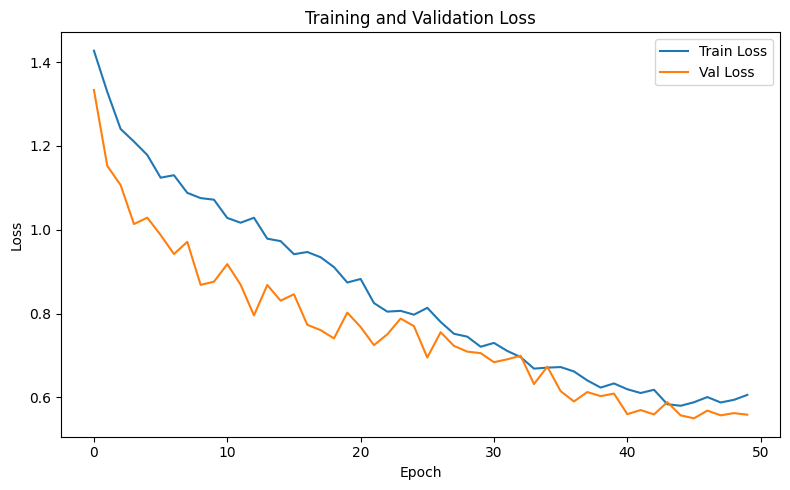

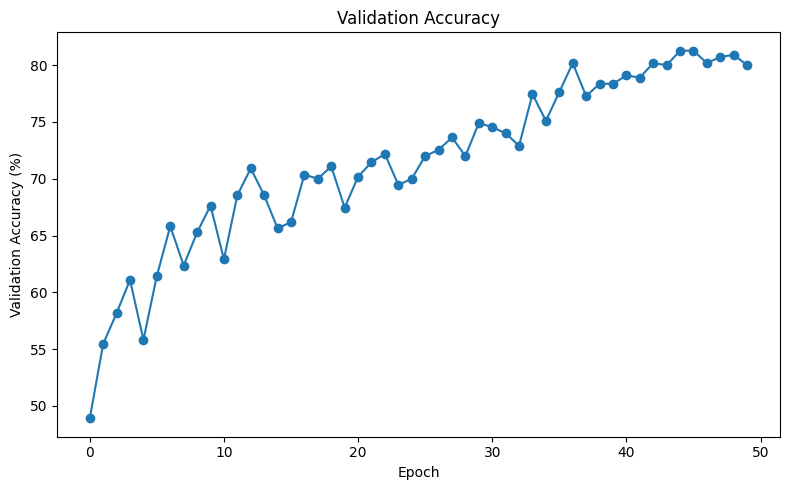

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(
    np.array(history["val_acc"]) * 100,
    marker="o"
)
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Validation Accuracy")
plt.tight_layout()
plt.show()


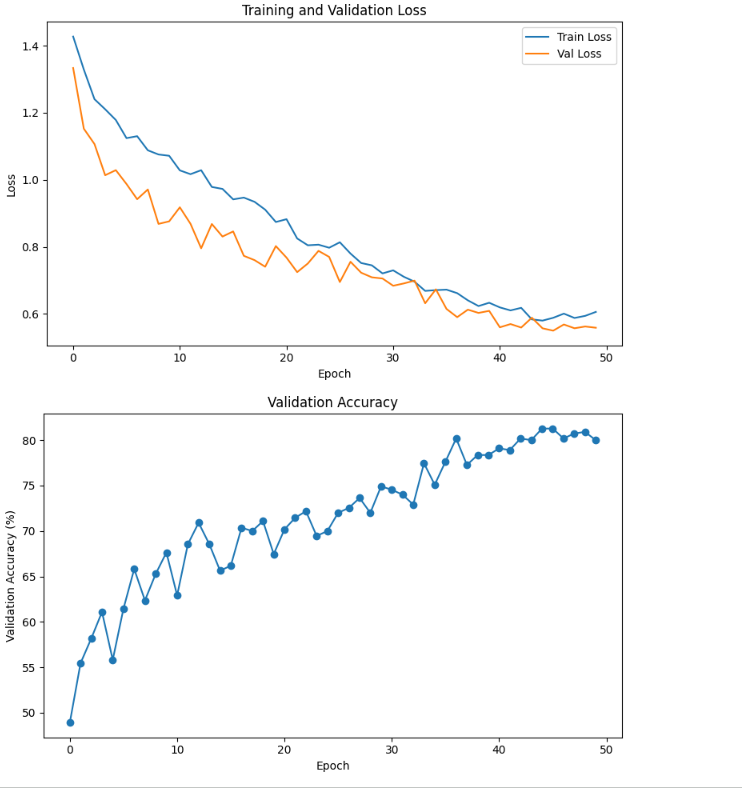

## Reload the Best Model

The model used for final testing is reloaded from the best validation checkpoint.

This prevents the final evaluation from accidentally using the final epoch when an earlier epoch had better validation performance.


In [ ]:
model = MediumCNN(num_classes=len(train_dataset.classes)).to(device)
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

print(f"Best model loaded from: {best_model_path}")
print(f"Best validation accuracy: {best_val_acc*100:.2f}%")


Best model loaded from: /content/best_medium_cnn_flowers.pth
Best validation accuracy: 81.27%


## Final Test Evaluation

The test split has not been used for training or model selection.

We now run the reloaded best model on the complete held-out test split and calculate:

- Accuracy
- Macro precision
- Macro recall
- Macro F1-score
- Per-class precision, recall, and F1
- Confusion matrix
- Test loss

The macro metrics give every flower class equal weight, which is useful when class frequencies are not perfectly balanced.


In [ ]:
!pip install -q scikit-learn

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

model.eval()

all_labels = []
all_predictions = []
all_confidences = []
test_loss = 0.0
total_samples = 0

with torch.no_grad():
    for X, y in tqdm(test_loader, desc="Final Test Evaluation"):
        X, y = X.to(device), y.to(device)

        logits = model(X)
        loss = loss_fn(logits, y)

        probabilities = torch.softmax(logits, dim=1)
        predictions = probabilities.argmax(dim=1)
        confidences = probabilities.max(dim=1).values

        test_loss += loss.item() * y.size(0)
        total_samples += y.size(0)

        all_labels.extend(y.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())
        all_confidences.extend(confidences.cpu().numpy())

test_loss = test_loss / total_samples

accuracy = accuracy_score(all_labels, all_predictions)

precision, recall, f1, _ = precision_recall_fscore_support(
    all_labels,
    all_predictions,
    labels=list(range(len(test_dataset.classes))),
    average="macro",
    zero_division=0
)

print("\n--- Final Held-Out Test Results ---")
print(f"Test Loss:       {test_loss:.4f}")
print(f"Accuracy:        {accuracy:.4f}")
print(f"Macro Precision: {precision:.4f}")
print(f"Macro Recall:    {recall:.4f}")
print(f"Macro F1:        {f1:.4f}")
print(f"Test Samples:    {total_samples}")


Final Test Evaluation:   0%|          | 0/69 [00:00<?, ?it/s]


--- Final Held-Out Test Results ---
Test Loss:       0.5117
Accuracy:        0.8385
Macro Precision: 0.8438
Macro Recall:    0.8436
Macro F1:        0.8388
Test Samples:    551


## Per-Class Metrics

Overall accuracy can hide weak performance on individual classes.

The classification report therefore shows precision, recall, F1-score, and support for each flower category.


In [ ]:
report = classification_report(
    all_labels,
    all_predictions,
    target_names=test_dataset.classes,
    digits=4,
    zero_division=0
)

print(report)


              precision    recall  f1-score   support

       daisy     0.9070    0.8571    0.8814        91
   dandelion     0.8258    0.9160    0.8685       119
       roses     0.6724    0.8478    0.7500        92
  sunflowers     0.9375    0.9052    0.9211       116
      tulips     0.8762    0.6917    0.7731       133

    accuracy                         0.8385       551
   macro avg     0.8438    0.8436    0.8388       551
weighted avg     0.8493    0.8385    0.8389       551



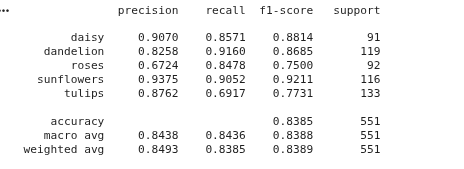

## Confusion Matrix

The confusion matrix shows which flower classes are being confused with one another.

This provides information that a single accuracy number cannot show, especially for visually similar categories.


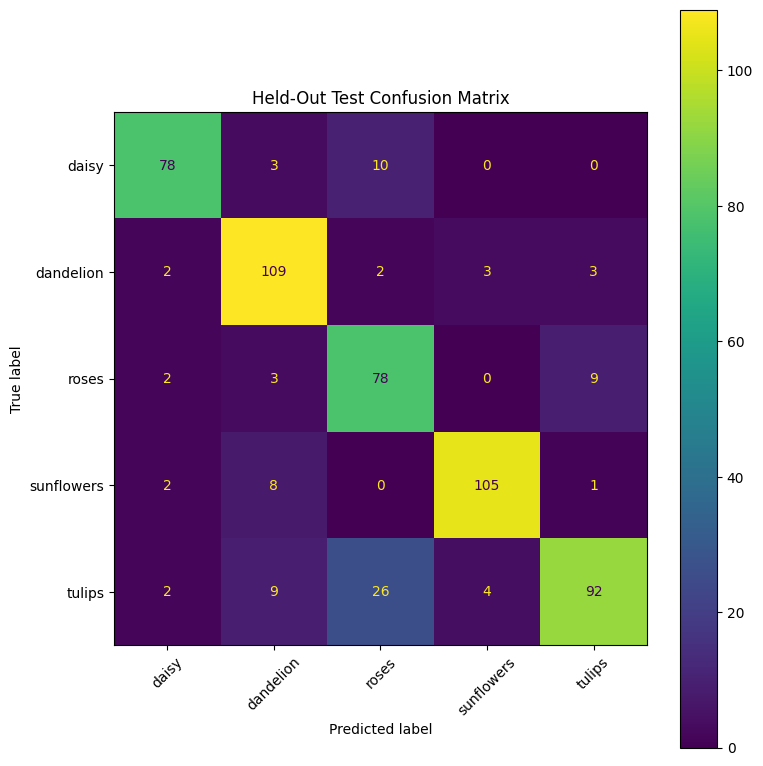

In [ ]:
cm = confusion_matrix(
    all_labels,
    all_predictions,
    labels=list(range(len(test_dataset.classes)))
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=test_dataset.classes
)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(
    ax=ax,
    xticks_rotation=45,
    values_format="d"
)
plt.title("Held-Out Test Confusion Matrix")
plt.tight_layout()
plt.show()


## Multiple Known Test Examples

A few individual predictions are useful for inspecting model behavior, but they are not the quantitative evaluation.

The examples below come directly from the held-out test set and therefore have known ground-truth labels.

For each example we show the input image, ground-truth class, predicted class, confidence, and correctness.


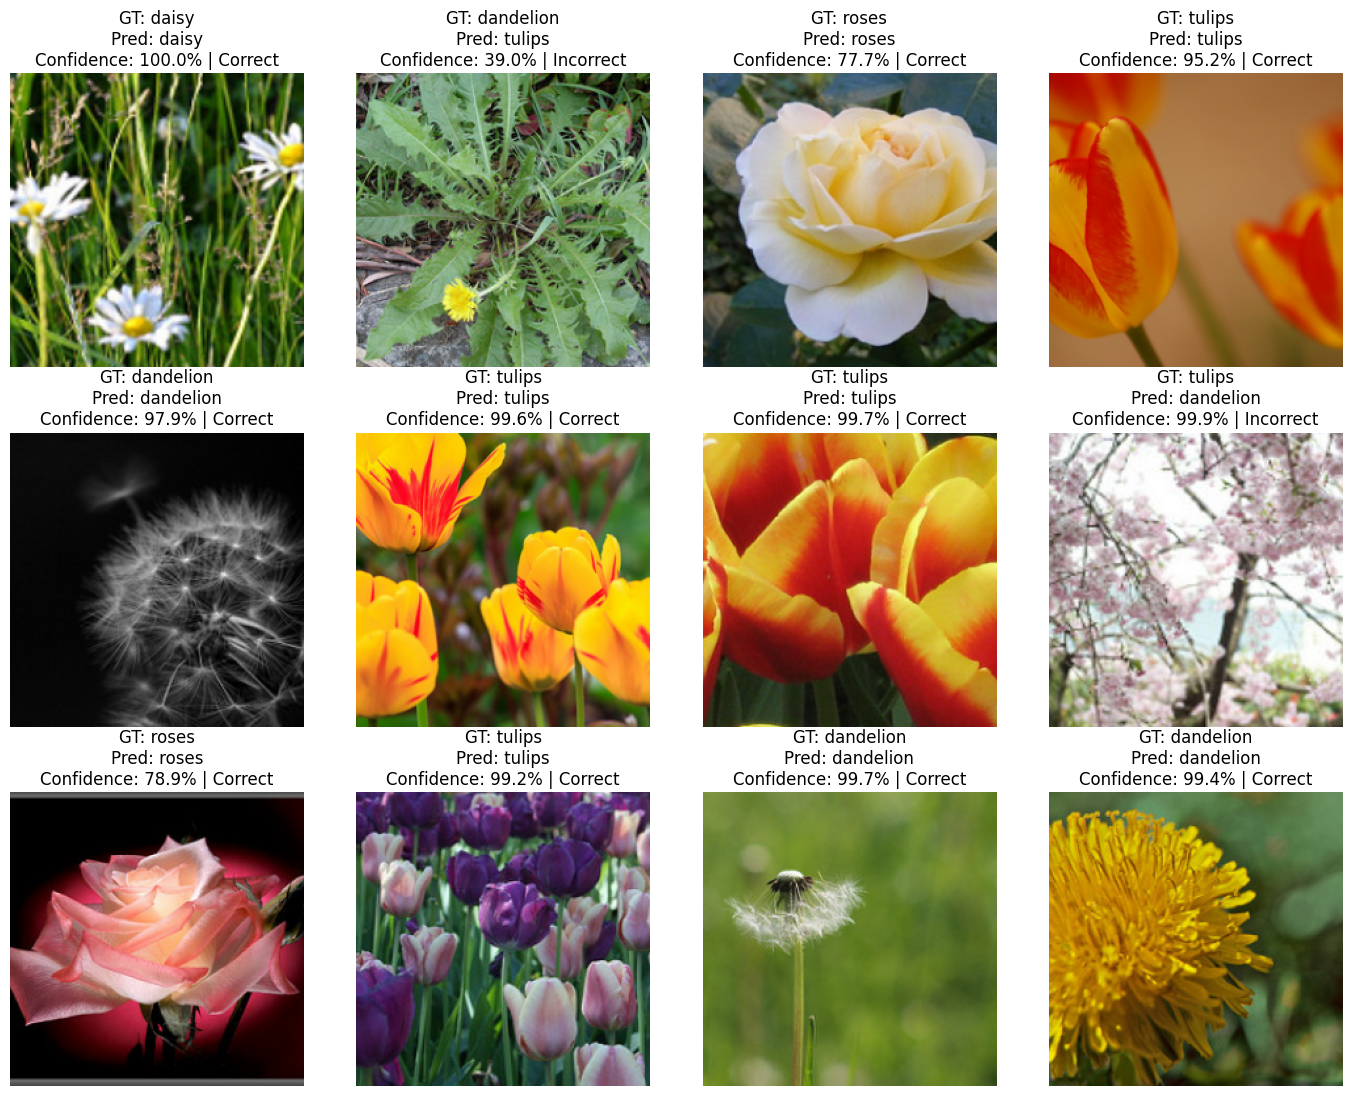

In [ ]:
num_examples = min(12, len(test_data))

fig, axes = plt.subplots(3,4,figsize=(14, 11))

axes = axes.flatten()

mean = torch.tensor([0.485, 0.456, 0.406])
std = torch.tensor([0.229, 0.224, 0.225])

model.eval()

for i in range(num_examples):
    image, label = test_data[i]

    with torch.no_grad():
        logits = model(image.unsqueeze(0).to(device))
        probabilities = torch.softmax(logits, dim=1)[0]
        prediction = int(probabilities.argmax().item())
        confidence = float(probabilities[prediction].item())

    display_image = image.cpu() * std[:, None, None] + mean[:, None, None]
    display_image = display_image.clamp(0, 1)

    axes[i].imshow(display_image.permute(1, 2, 0))
    axes[i].axis("off")

    correct = prediction == label
    status = "Correct" if correct else "Incorrect"

    axes[i].set_title(
        f"GT: {test_dataset.classes[label]}\n"
        f"Pred: {test_dataset.classes[prediction]}\n"
        f"Confidence: {confidence*100:.1f}% | {status}"
    )

for i in range(num_examples, len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()


## Test Prediction Table

The same held-out examples are also summarized in a table so the prediction, ground truth, confidence, and correctness can be inspected without relying only on the visualization.


In [ ]:
prediction_rows = []

for i in range(num_examples):
    image, label = test_data[i]

    with torch.no_grad():
        logits = model(image.unsqueeze(0).to(device))
        probabilities = torch.softmax(logits, dim=1)[0]
        prediction = int(probabilities.argmax().item())
        confidence = float(probabilities[prediction].item())

    prediction_rows.append({
        "Example": i + 1,
        "Ground Truth": test_dataset.classes[label],
        "Prediction": test_dataset.classes[prediction],
        "Confidence": confidence,
        "Correct": prediction == label
    })

prediction_df = pd.DataFrame(prediction_rows)
display(prediction_df.round(4))


,Example,Ground Truth,Prediction,Confidence,Correct
0,1,daisy,daisy,0.9999,True
1,2,dandelion,tulips,0.3900,False
2,3,roses,roses,0.7772,True
3,4,tulips,tulips,0.9519,True
4,5,dandelion,dandelion,0.9787,True
5,6,tulips,tulips,0.9958,True
6,7,tulips,tulips,0.9971,True
7,8,tulips,dandelion,0.9989,False
8,9,roses,roses,0.7888,True
9,10,tulips,tulips,0.9925,True


## Final Quantitative Summary

The final result is based on the complete held-out test split, not the small set of examples shown above.

The validation accuracy was used for model selection. The test metrics were calculated only after the best checkpoint was reloaded.


In [ ]:
final_results = {
    "Best Validation Accuracy": best_val_acc,
    "Test Loss": test_loss,
    "Test Accuracy": accuracy,
    "Macro Precision": precision,
    "Macro Recall": recall,
    "Macro F1": f1,
    "Test Samples": total_samples
}

for key, value in final_results.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")


Best Validation Accuracy: 0.8127
Test Loss: 0.5117
Test Accuracy: 0.8385
Macro Precision: 0.8438
Macro Recall: 0.8436
Macro F1: 0.8388
Test Samples: 551


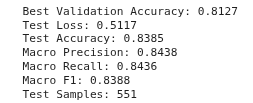

## Conclusion

This notebook implements a custom residual CNN from scratch and evaluates it using a controlled train/validation/test protocol.

The important distinction is:

- **Training set:** used to learn model parameters.
- **Validation set:** used to monitor generalization and select the best checkpoint.
- **Test set:** kept untouched until final evaluation.

The final test evaluation reports objective classification metrics rather than relying only on example predictions.

The experiment demonstrates:

- Custom residual-block implementation.
- Native PyTorch training.
- Reproducible dataset splitting.
- Separate deterministic validation/test preprocessing.
- Best-checkpoint selection.
- Reloading the selected model before testing.
- Multiple known test examples with ground-truth labels.
- Accuracy, macro precision, macro recall, macro F1, and per-class metrics.
- Confusion-matrix analysis.

This should be described as a **controlled five-class flower classification experiment**, not as a benchmark.
